In [9]:
from pathlib import Path
import os, sys, random, time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.utils.data import DataLoader
from scipy import stats

# Repo paths
ROOT = Path.cwd().resolve().parents[0]
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Local modules
from data.sample_x import sample_x
from data.solve_ode import SpringParams, simulate_spring
from data.datasets import SpringDataset, make_sequence_pairs
from train.models import build_cond_gru_model, EncoderOnly
from train.training import (
    train_epoch,
    train_epoch_mmd_only,
    eval_epoch,
    eval_epoch_enc,
)
from train.losses import mmd2_unif
from hypo_test.stats_tests import chisq_uniform_1d

# Global config
class Cfg:
    seed = 1
    n_samples = 5000
    T = 10.0
    dt = 0.05
    stride = 1
    dist_mean = np.array([0., 0.])
    dist_cov = np.diag([1., 1.])
    batch_train = 64
    batch_val = 128
    epochs = 30
    lr = 5e-3
    weight_decay = 1e-5
    lambda_mmd = 1e-1
    d_x = 2
    d_o = 1
    d_v = 1
    d_h = 64
    hidden_enc = 128
    hidden_dec = 128
    B_bins = 10  # chi-square bins

# Reproducibility
torch.manual_seed(Cfg.seed)
np.random.seed(Cfg.seed)
random.seed(Cfg.seed)

# Device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("device:", device)


device: mps


In [5]:
z_0 = np.array([0.0, 0.0]) # baselien config
params = SpringParams(mass=1.0, damping=1.0, stiffness=2.0) # paramters theta

X = sample_x(
    n_samples=Cfg.n_samples,
    dist_type="gaussian",
    params={"mean": Cfg.dist_mean, "cov": Cfg.dist_cov},
    seed=Cfg.seed,
)

traj = simulate_spring(params, t_final=Cfg.T, dt=Cfg.dt, X=X, forcing_type="sin", config=z_0)
s = traj["s"]                           # (N, T_full)
assert X.shape[0] == s.shape[0]

o_hist,o_next = make_sequence_pairs( s=s,stride=Cfg.stride)
x_np   = X.astype(np.float32)

print("Shapes -> X:", x_np.shape, "o_hist:", o_hist.shape, "o_next:", o_next.shape)


Shapes -> X: (2000, 2) o_hist: (2000, 200, 1) o_next: (2000, 200, 1)


In [7]:
N = x_np.shape[0]
perm = np.random.RandomState(Cfg.seed).permutation(N)
n_train = int(0.8 * N)
tr_idx, va_idx = perm[:n_train], perm[n_train:]

train_ds = SpringDataset(x_np[tr_idx], o_hist[tr_idx], o_next[tr_idx])
val_ds   = SpringDataset(x_np[va_idx], o_hist[va_idx], o_next[va_idx])

train_loader = DataLoader(train_ds, batch_size=Cfg.batch_train, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=Cfg.batch_val, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")


Train batches: 25, Val batches: 4


In [11]:
model = build_cond_gru_model(
    d_x=Cfg.d_x,
    d_o=Cfg.d_o,
    d_v=Cfg.d_v,
    d_h=Cfg.d_h,
    hidden_enc=Cfg.hidden_enc,
    hidden_dec=Cfg.hidden_dec,
    output_activation="sigmoid",
).to(device)

# Encoder-only variant for pure latent uniform MMD loss regularization.
model_enc = EncoderOnly(model.enc).to(device)

opt = torch.optim.Adam(model.parameters(), lr=Cfg.lr, weight_decay=Cfg.weight_decay)
opt_enc = torch.optim.Adam(model_enc.parameters(), lr=Cfg.lr, weight_decay=Cfg.weight_decay)


history = []
best_val_mmd = float("inf")
best_state = None

for epoch in range(1, Cfg.epochs + 1):
    tr_loss = train_epoch(model, train_loader, opt, Cfg.lambda_mmd, device)
    va_rec, va_mmd = eval_epoch(val_loader, model, device)

    tr_mmd_enc = train_epoch_mmd_only(model_enc, train_loader, opt_enc, Cfg.lambda_mmd, device)
    va_mmd_enc = eval_epoch_enc(val_loader, model_enc, device)

    history.append({
        "epoch": epoch,
        "tr_loss": tr_loss,
        "va_rec": va_rec,
        "va_mmd": va_mmd,
        "tr_mmd_enc": tr_mmd_enc,
        "va_mmd_enc": va_mmd_enc,
    })

    if va_mmd < best_val_mmd:
        best_val_mmd = va_mmd
        best_state = model.state_dict()

    if epoch % 5 == 0 or epoch == 1:
        print(f"[{epoch:02d}] tr_loss={tr_loss:.4f}  va_rec={va_rec:.4f}  va_mmd={va_mmd:.4f}  "
              f"enc_mmd(tr/va)={tr_mmd_enc:.4f}/{va_mmd_enc:.4f}")

if best_state is not None:
    model.load_state_dict(best_state)

pd.DataFrame(history).tail()


[01] tr_loss=0.0289  va_rec=0.0038  va_mmd=0.0053  enc_mmd(tr/va)=0.0004/0.0023
[05] tr_loss=0.0004  va_rec=0.0000  va_mmd=-0.0011  enc_mmd(tr/va)=0.0004/-0.0037
[10] tr_loss=0.0001  va_rec=0.0001  va_mmd=-0.0002  enc_mmd(tr/va)=0.0003/0.0011
[15] tr_loss=0.0006  va_rec=0.0002  va_mmd=0.0008  enc_mmd(tr/va)=0.0001/0.0001
[20] tr_loss=0.0002  va_rec=0.0000  va_mmd=-0.0045  enc_mmd(tr/va)=0.0003/-0.0030
[25] tr_loss=-0.0000  va_rec=0.0000  va_mmd=0.0025  enc_mmd(tr/va)=0.0004/-0.0013
[30] tr_loss=0.0001  va_rec=0.0000  va_mmd=0.0052  enc_mmd(tr/va)=0.0004/0.0040


,epoch,tr_loss,va_rec,va_mmd,tr_mmd_enc,va_mmd_enc
25,26,-0.000043,0.000021,-0.003244,0.000266,0.002544
26,27,0.000068,0.000045,-0.004996,0.000508,0.004508
27,28,0.000013,0.000043,-0.001759,-0.000125,-0.000699
28,29,0.000184,0.000085,0.002053,0.000624,0.000057
29,30,0.000098,0.000036,0.005169,0.000441,0.003992


In [12]:
@torch.no_grad()
def encode_to_latent(model_any, X_array, device, batch_size=1024):
    X_tensor = torch.tensor(X_array, dtype=torch.float32, device=device)
    vs = []
    for start in range(0, X_tensor.shape[0], batch_size):
        xb = X_tensor[start:start+batch_size]
        if hasattr(model_any, "enc"):
            vb = model_any.enc(xb)
        else:
            vb = model_any(xb)
        vs.append(vb.detach().cpu())
    return torch.cat(vs, dim=0).numpy()

def stats_for_latents(v, B=Cfg.B_bins):
    v = np.asarray(v)
    ks_p   = stats.kstest(v[:, 0], "uniform", args=(0, 1)).pvalue  # d_v=1 here
    cvm_p  = stats.cramervonmises(v[:, 0], "uniform", args=(0, 1)).pvalue
    _, chi2_p, _ = chisq_uniform_1d(v[:, 0], b=B)
    return ks_p, cvm_p, chi2_p


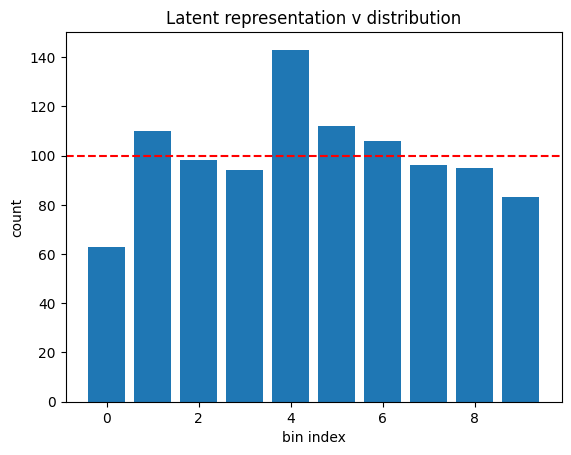

In [15]:
X_splits = {
    "X_train": x_np[tr_idx],
    "X_val":   x_np[va_idx],
    "X_test":  sample_x(
        n_samples=1000,
        dist_type="gaussian",
        params={"mean": np.array([0, 0]), "cov": np.diag([1, 1])},
        seed=5,
    ).astype(np.float32),
}


v_samp = latents_rec = encode_to_latent(model, X_splits["X_test"], device)
B = Cfg.B_bins
counts, edges = np.histogram(v_samp[:, 0], bins=B, range=(0, 1))
expected = len(v_samp) / B

plt.figure()
plt.bar(range(B), counts)
plt.axhline(expected, linestyle="--", color="red")
plt.xlabel("bin index")
plt.ylabel("count")
plt.title("Latent representation v distribution")
plt.show()
